In [76]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 14

import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten #, Reshape
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D

%run plot.py

### Read data

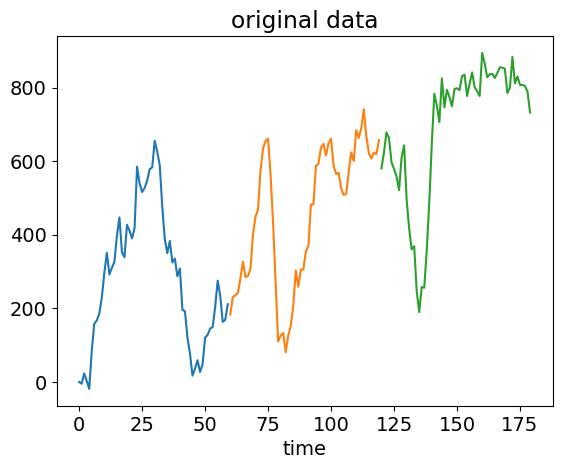

data:  10000


In [77]:
str0 = 'ts_L60_Z12_A500_DX50_bias5_N10000.dat'
fnamex='DATA/x_'+str0
fnamey='DATA/y_'+str0

x = np.loadtxt(fnamex, delimiter=" ",dtype=float)
# number of samples, number of features
N,L = len(x), len(x[0])

Show_data(x,L,"original data")

categ = np.loadtxt(fnamey, dtype=int)
n_class = 3    # y.argmax() - y.argmin() +1
print('data: ',N)

y = np.zeros((N,n_class))
for i in range(N):
    y[i][categ[i]] = 1. # y contains one-hot encoding

### Split train-validation and rescale

(8000, 60)
N_train= 8000   N_val= 2000   L= 60   n_class= 3
std_train average and mean: 588.25397835931 44.84287073276593 201.46657645528722
std_val average and mean: 569.9090424503428 55.06717110341998 201.92178219610327


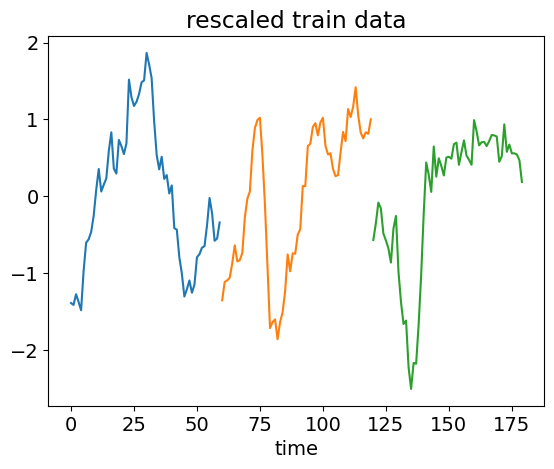

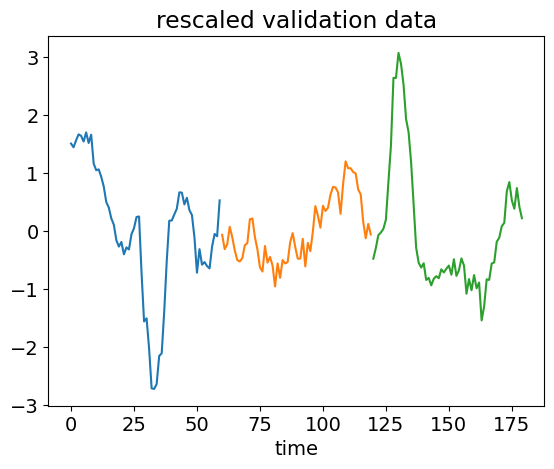

In [78]:
# split into training and validation sets
perc_train=0.8
N_train = int(perc_train*N)
x_train = x[:N_train]
print(x_train.shape)
y_train = y[:N_train]
x_val = x[N_train:]
y_val = y[N_train:]
N_val = len(x_val)
print('N_train=',N_train,'  N_val=',N_val,'  L=',L,'  n_class=',n_class)

 
#remove average value of each sample from its values
xm_train = x_train.mean(axis=1)
std_train = x_train.std(axis=1)
xm_val = x_val.mean(axis=1)
std_val = x_val.std(axis=1)
print('std_train average and mean:',max(std_train), min(std_train), std_train.mean(axis=0))
print('std_val average and mean:',max(std_val), min(std_val), std_val.mean(axis=0))

# rescale with variance on the training set
for i in range(N_train):
    #x_train[i] = (x_train[i]-xm_train[i])/ std_train[i] #not good, std_train is very variable across samples
     #x_train[i] = (x_train[i]-xm_train[i])/ 400 #crude rescaling, variance should be used
     x_train[i] = (x_train[i]-xm_train[i])/ std_train.mean(axis=0)
for i in range(N_val):
    #x_val[i] = (x_val[i]-xm_val[i])/ std_val[i]
    #x_val[i] = (x_val[i]-xm_val[i])/ 400
    x_val[i] = (x_val[i]-xm_val[i])/ std_val.mean(axis=0)
#

    
Show_data(x_train,L,"rescaled train data")
Show_data(x_val,L,"rescaled validation data")

#x_train=x_train.astype("float32")
#y_train=y_train.astype("float32")
#x_val=x_val.astype("float32")
#y_val=y_val.astype("float32")

# Keras wants an additional dimension with a 1 at the end
x_train = x_train.reshape(x_train.shape[0], L, 1)
x_val =  x_val.reshape(x_val.shape[0], L, 1)
input_shape = (L, 1) # number of features, number of channels (1 for 1D data)

## Convolutional NN

In [79]:
# ...LESSON ...
# reproducibility
np.random.seed(12345)
import tensorflow.random as tf_r
tf_r.set_seed(12345)

## from keras import regularizers, initializers

def model_constructor(reg):

    ini = tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.05, 
                                            seed=None)

    NF = 5 #number of filters

    # challenge: at most 600 tunable parameters
    model = Sequential()

    model.add(Conv1D(filters=NF, kernel_size=11, 
                        kernel_initializer=ini, 
                        kernel_regularizer=reg,
                        activation='relu', 
                        input_shape=input_shape))
    #model.add(MaxPooling1D(3))
    model.add(AveragePooling1D(5))
    model.add(Conv1D(filters=5, kernel_size=7, 
                        activation='relu'))
    model.add(Flatten())
    model.add(Dense(12, activation='relu'))
    model.add(Dropout(0.2))
    
    model.add(Dense(n_class, activation='softmax'))

    #print(model.summary())

    # optimizers
    # .SGD(lr=0.01, momentum=0.9, nesterov=True) # decay=1e-6,
    # .RMSprop()
    # .Nadam()
    opt = tf.keras.optimizers.Adam()

    # compile the model
    # categorical_crossentropy, 3 output nodes
    model.compile(loss=keras.losses.categorical_crossentropy,
                optimizer=opt,metrics=['accuracy'])
    
    return model

In [103]:
def Show_weights(model,l=0,label="model"):
    c=['r','y','c','b','m']
    m=['o','s','D','<','>']
    ms=10
    
    w = model.layers[l].get_weights()[0] # weights
    print(w.shape)
    wT=w.T
    print(wT.shape)
    M=len(wT)
    b = model.layers[l].get_weights()[1] # bias
    
    fig,AX=plt.subplots(1,2,figsize=(12,4.4))
    ax=AX[0]
    ax.axhline(0, c="k")
    ax.plot((0,))
    for i in range(M):
        ax.plot(wT[i][0],"-",c=c[i],marker=m[i],label=str(i),markersize=ms)
    ax.set_title(label+': filters of layer '+str(l))
    ax.set_xlabel('index')
    ax=AX[1]
    ax.axhline(0, c="k")
    for i in range(M):
        ax.plot((i),(b[i]),c=c[i],marker=m[i],label="filter "+str(i),markersize=ms)
    ax.set_title(label+': bias of layer '+str(l))
    ax.set_xlabel('filter nr')
    ax.set_xticks(np.arange(5))
    ax.legend()
    plt.show()

In [80]:
# ...LESSON ...
# Hyper-parameters
# with small minibatch it does not converge!! 
BATCH_SIZE = 200
EPOCHS = 150

lambda_pars = [10**-5, 10**-4, 10**-3, 10**-2, 10**-1]

/home/matteocalcagni/Desktop/LCP_modB/keras_env/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


(11, 1, 5)
(5, 1, 11)


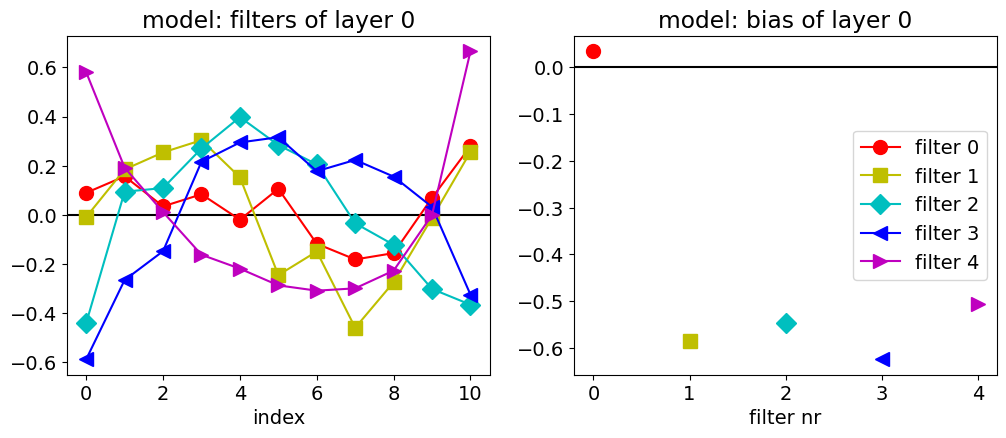

(11, 1, 5)
(5, 1, 11)


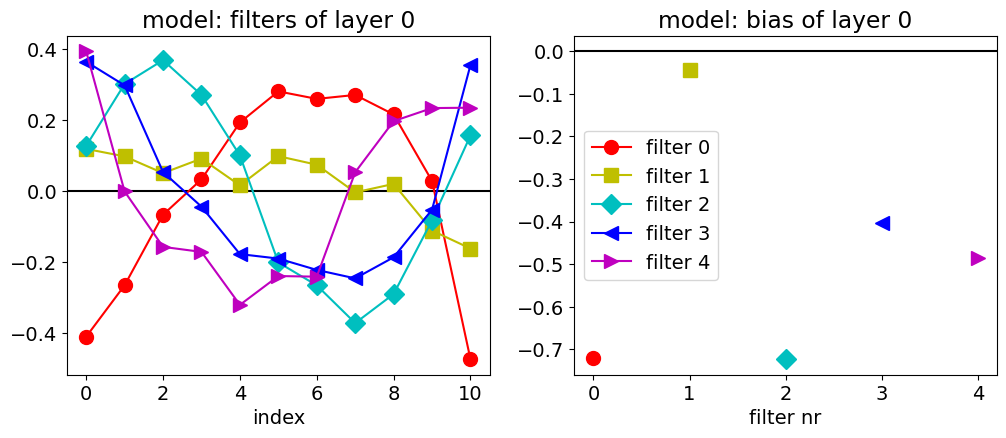

(11, 1, 5)
(5, 1, 11)


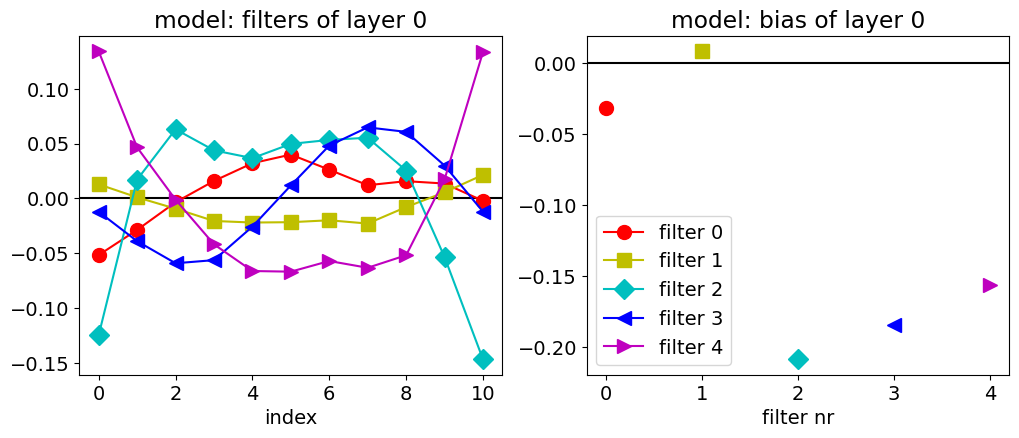

In [105]:
# In the end I will have a dictionary of dictionaries containing the information on the fitting
# results of each model
l2_results = {} 

for l in lambda_pars:

    reg = tf.keras.regularizers.l2(l)
    model = model_constructor(reg)

    fit = model.fit(x_train,y_train,batch_size=BATCH_SIZE,
                    epochs=EPOCHS,
                    validation_data=(x_val, y_val),
                    verbose=0, shuffle=True) 
    
    l2_results[l] = fit.history
    
    if(l==10**-5 or l==0.001 or l==0.1):
        Show_weights(model, 0)

(11, 1, 5)
(5, 1, 11)


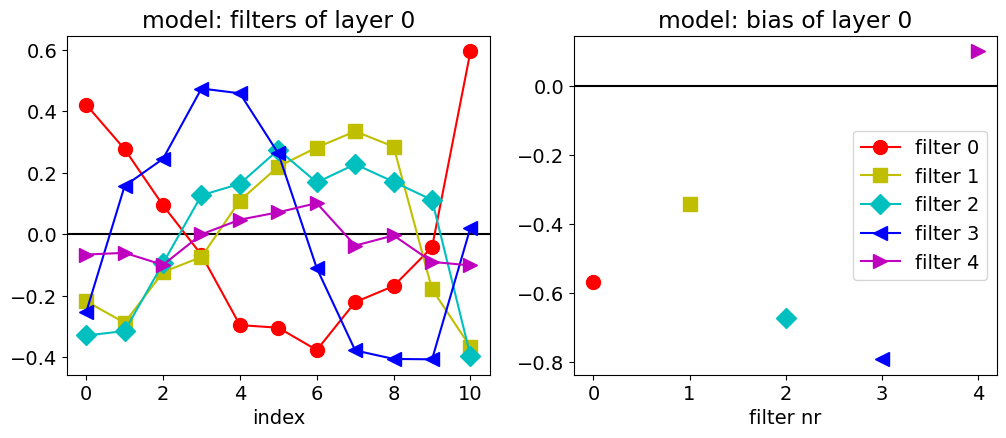

(11, 1, 5)
(5, 1, 11)


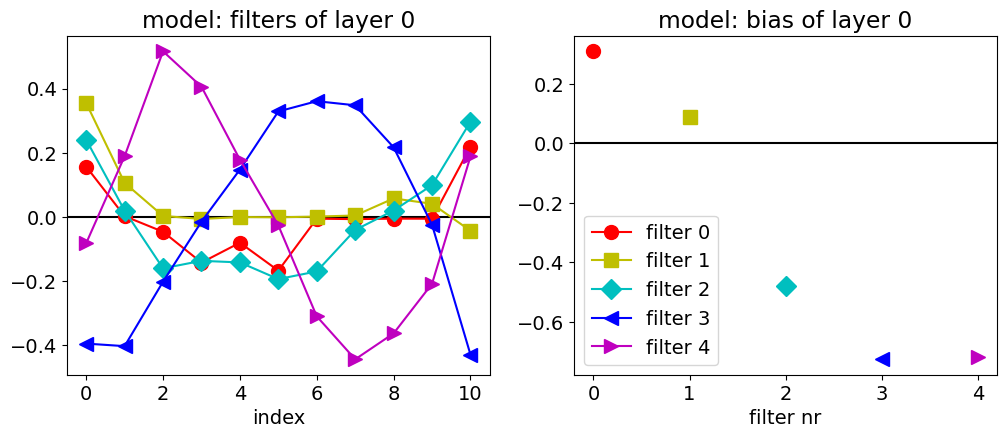

(11, 1, 5)
(5, 1, 11)


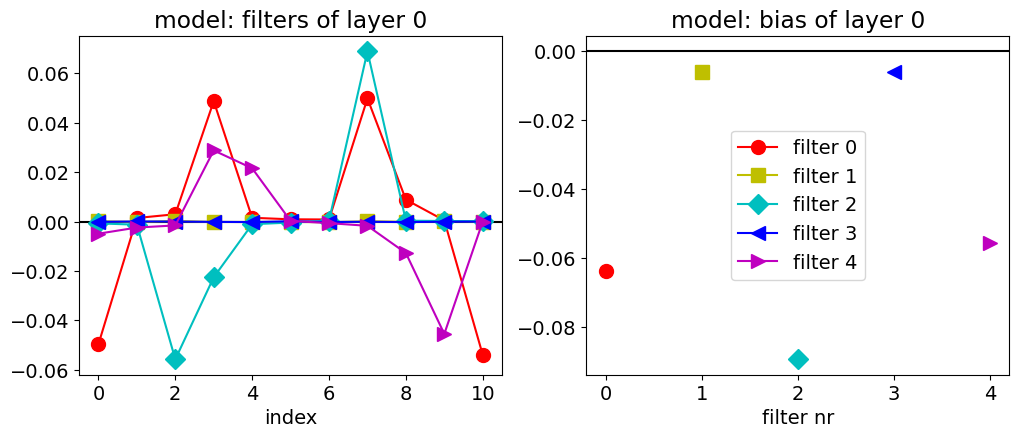

In [106]:
l1_results = {} 

for l in lambda_pars:

    reg = tf.keras.regularizers.l1(float(l))
    model = model_constructor(reg)

    fit = model.fit(x_train,y_train,batch_size=BATCH_SIZE,
                    epochs=EPOCHS,
                    validation_data=(x_val, y_val),
                    verbose=0, shuffle=True) 
    
    l1_results[l] = fit.history
    
    if(l==10**-5 or l==0.001 or l==0.1):
        Show_weights(model, 0)

In [107]:
import pandas as pd
import os 

l2_outfile = "l2_results.csv"
l1_outfile = "l1_results.csv"

if os.path.isfile(l2_outfile):
    os.remove(l2_outfile)
if os.path.isfile(l1_outfile):
    os.remove(l1_outfile)

# Write the l2 results into a csv file

metadata = [
    "# Experiment: L2 Regularization Parameter Sweep\n",
    "# Batch Size: 200\n",
    "# Epochs: 150\n",
    "# -------------------------------------------"
]

with open(l2_outfile, mode='a') as f:

    f.writelines(metadata)

    for l in lambda_pars:
        f.writelines(f"\n\n# Results with lambda equal to {l}\n\n")
        pd.DataFrame(l2_results[l]).to_csv(f, index=False)

# Write the l1 results into a csv file

metadata = [
    "# Experiment: L1 Regularization Parameter Sweep\n",
    "# Batch Size: 200\n",
    "# Epochs: 150\n",
    "# -------------------------------------------"
]

with open(l1_outfile, mode='a') as f:

    f.writelines(metadata)

    for l in lambda_pars:
        f.writelines(f"\n\n# Results with lambda equal to {l}\n\n")
        pd.DataFrame(l1_results[l]).to_csv(f, index=False)


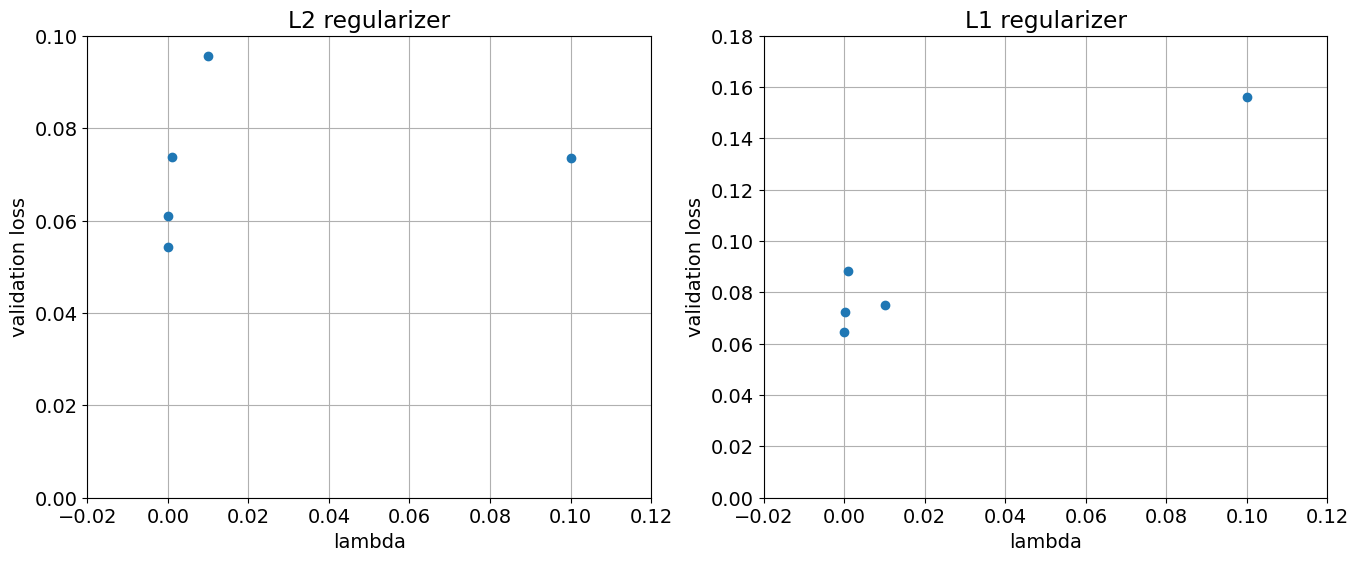

In [110]:
l2_val_losses = [l2_results[l]["val_loss"][-1] for l in lambda_pars]
l1_val_losses = [l1_results[l]["val_loss"][-1] for l in lambda_pars]

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

ax1.plot(lambda_pars, l2_val_losses, marker='o', linestyle='None')
ax1.set_xlabel("lambda"); ax1.set_ylabel("validation loss")
ax1.set_title("L2 regularizer")
ax1.set_xbound(-0.02, 0.12); ax1.set_ybound(0, 0.1)
ax1.grid()

ax2.plot(lambda_pars, l1_val_losses, marker='o', linestyle='None')
ax2.set_xlabel("lambda"); ax2.set_ylabel("validation loss")
ax2.set_title("L1 regularizer")
ax2.set_xbound(-0.02, 0.12); ax2.set_ybound(0, 0.18)
ax2.grid()

plt.show()